Cell 1 — Install WS package if needed

In [1]:
import importlib.util
import subprocess
import sys

def ensure_package(import_name: str, pip_name: str | None = None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"{import_name} already installed.")

ensure_package("kymatio", "kymatio")
ensure_package("sklearn", "scikit-learn")

Installing kymatio ...
sklearn already installed.


Cell 2 — Imports and paths

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from kymatio.numpy import Scattering2D

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.neighbors import KNeighborsClassifier

ROOT = Path(".")
PATCH_ROOT = ROOT / "data" / "processed" / "patches_v1"
WS_ROOT = ROOT / "data" / "processed" / "ws_v1"
WS_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = PATCH_ROOT / "manifest.csv"
RANDOM_STATE = 34

Cell 3 — Load the patch manifest

This reads the manifest you created during patch extraction and keeps only the two background classes.


What this cell is doing

Your WS branch should start from the saved 224×224 patch dataset, not from the full mammograms. That matches the paper’s workflow: patch first, then feature extraction from the patches. 

In [3]:
def normalize_local_path(p):
    return Path(str(p).replace("\\", "/"))

manifest = pd.read_csv(MANIFEST_PATH)

manifest = manifest[manifest["label"].isin(["fatty", "fibroglandular"])].copy()
manifest["patch_npy"] = manifest["patch_npy"].apply(normalize_local_path)

# Keep only rows whose patch files actually exist
manifest = manifest[manifest["patch_npy"].apply(lambda p: p.exists())].reset_index(drop=True)

label_map = {"fatty": 0, "fibroglandular": 1}
manifest["class_id"] = manifest["label"].map(label_map)

print("Number of WS input patches:", len(manifest))
print(manifest["label"].value_counts())
display(manifest.head())

Number of WS input patches: 397
label
fatty             210
fibroglandular    187
Name: count, dtype: int64


,file_id,label,patch_npy,patch_png,source_final_npy,source_breast_mask_npy,source_pect_mask_npy,xml_path,threshold,orig_size,y0,y1,x0,x1,allowed_frac,target_frac,mean_intensity,std_intensity,class_id
0,20586908,fatty,data\processed\patches_v1\background\fatty\205...,data\processed\patches_v1\background\fatty\205...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,887,1159,1958,2230,1.0,0.864751,0.523079,0.109092,0
1,20586908,fatty,data\processed\patches_v1\background\fatty\205...,data\processed\patches_v1\background\fatty\205...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,244,516,2691,2963,1.0,0.712219,0.604453,0.060220,0
2,20586908,fatty,data\processed\patches_v1\background\fatty\205...,data\processed\patches_v1\background\fatty\205...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,2080,2352,2066,2338,1.0,0.756752,0.583349,0.112752,0
3,20586908,fibroglandular,data\processed\patches_v1\background\fibroglan...,data\processed\patches_v1\background\fibroglan...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,351,1415,1765,1848,2198,1.0,0.762096,0.836919,0.135106,1
4,20586908,fibroglandular,data\processed\patches_v1\background\fibroglan...,data\processed\patches_v1\background\fibroglan...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,data\raw\AllXML\20586908.xml,0.681258,273,713,985,2740,3012,1.0,0.698855,0.783806,0.107647,1


Cell 4 — Create and save the 80:20 split

The paper says the data is divided in an 8:2 randomized ratio, and the same split is reused for manual textural extraction so it stays compatible with later CNN fusion.

What this cell is doing

This gives you one fixed split that you can reuse later for CNN and fusion as well.

In [4]:
train_idx, test_idx = train_test_split(
    manifest.index,
    test_size=0.20,
    stratify=manifest["class_id"],
    random_state=RANDOM_STATE,
    shuffle=True,
)

manifest["split"] = "train"
manifest.loc[test_idx, "split"] = "test"

split_manifest_path = WS_ROOT / "ws_manifest_split.csv"
manifest.to_csv(split_manifest_path, index=False)

print("Saved split manifest to:", split_manifest_path)
print("\nCounts by split and label:")
display(pd.crosstab(manifest["split"], manifest["label"]))

Saved split manifest to: data\processed\ws_v1\ws_manifest_split.csv

Counts by split and label:


label,fatty,fibroglandular
split,,
test,42,38
train,168,149


Cell 5 — Define the WS configuration and helper functions

The paper explicitly states an invariance scale of 64 for 224×224 input patches. In scattering notation, that corresponds to J = log2(64) = 6. The paper also says the final WS representation has 391 predictors per image.

What this cell is doing

This is the core WS setup. We keep the input exactly at 224×224, use invariance scale 64, and convert the scattering output into one feature vector per patch.

In [5]:
# Paper-aligned core setting
INVARIANCE_SCALE = 64
J = int(np.log2(INVARIANCE_SCALE))   # 6 for scale 64
L = 5                                # practical Python reconstruction to target ~391 predictors
PATCH_SHAPE = (224, 224)

scattering = Scattering2D(
    J=J,
    shape=PATCH_SHAPE,
    L=L,
    max_order=2,
)

def load_patch01(path: Path) -> np.ndarray:
    """
    Load a single saved patch and make sure it is a clean float32 array in [0, 1].
    """
    arr = np.load(path).astype(np.float32)

    if arr.shape != PATCH_SHAPE:
        raise ValueError(f"Expected patch shape {PATCH_SHAPE}, got {arr.shape} for {path}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)
    arr = np.clip(arr, 0.0, 1.0)
    return arr

def ws_feature_vector(patch01: np.ndarray, scattering_obj: Scattering2D) -> np.ndarray:
    """
    Compute a 1D WS feature vector from one 224x224 patch.

    Kymatio returns scattering coefficient maps. We average each coefficient map
    spatially to get one scalar per coefficient path, which is the most natural
    way to form a compact predictor vector here.
    """
    S = scattering_obj(patch01)  # usually shape: (C, Hs, Ws)

    if S.ndim == 3:
        feat = S.mean(axis=(1, 2))
    elif S.ndim == 1:
        feat = S
    else:
        raise ValueError(f"Unexpected scattering output shape: {S.shape}")

    return feat.astype(np.float32)

Cell 6 — Sanity check one patch and one WS vector

This is the most important debug cell before batch extraction.

What to look for

You want:

no shape errors

a sensible WS feature length

coefficients that are not all zero or all identical

If the feature length is not exactly 391, do not panic. The paper gives 391 from its MATLAB setup, but Python libraries can differ slightly while still following the same WS idea. The more important things are the patch size, invariance scale, and having a stable per-patch WS vector.

Sample label: fatty
Patch shape: (224, 224)
WS feature length: 406


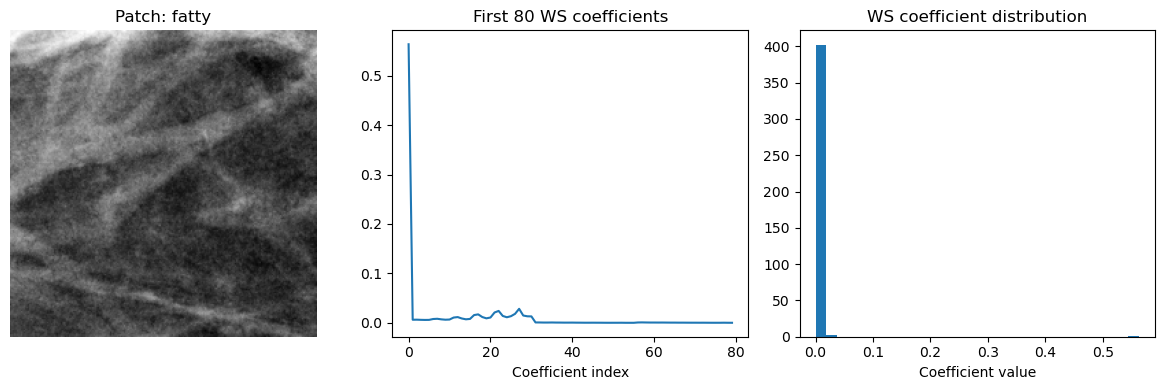

In [6]:
sample_row = manifest.iloc[0]
sample_patch = load_patch01(sample_row["patch_npy"])
sample_feat = ws_feature_vector(sample_patch, scattering)

print("Sample label:", sample_row["label"])
print("Patch shape:", sample_patch.shape)
print("WS feature length:", len(sample_feat))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_patch, cmap="gray")
plt.title(f"Patch: {sample_row['label']}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(sample_feat[:80])
plt.title("First 80 WS coefficients")
plt.xlabel("Coefficient index")

plt.subplot(1, 3, 3)
plt.hist(sample_feat, bins=30)
plt.title("WS coefficient distribution")
plt.xlabel("Coefficient value")

plt.tight_layout()
plt.show()

Cell 7 — Batch-extract WS features for all patches

This computes the WS vector for every saved background patch.

What this cell is doing

At the end of this cell, each row is one patch and each ws_... column is one scattering predictor.

In [7]:
records = []

for row in tqdm(manifest.itertuples(index=False), total=len(manifest), desc="Extracting WS features"):
    patch = load_patch01(row.patch_npy)
    feat = ws_feature_vector(patch, scattering)

    rec = {
        "file_id": row.file_id,
        "label": row.label,
        "class_id": row.class_id,
        "split": row.split,
        "patch_npy": str(row.patch_npy),
    }

    for j, val in enumerate(feat):
        rec[f"ws_{j:03d}"] = float(val)

    records.append(rec)

ws_df = pd.DataFrame(records)

ws_csv_path = WS_ROOT / "ws_features.csv"
ws_npy_path = WS_ROOT / "ws_features.npy"

feature_cols = [c for c in ws_df.columns if c.startswith("ws_")]
X_all = ws_df[feature_cols].to_numpy(dtype=np.float32)

ws_df.to_csv(ws_csv_path, index=False)
np.save(ws_npy_path, X_all)

print("Saved WS features CSV:", ws_csv_path)
print("Saved WS features NPY:", ws_npy_path)
print("Feature matrix shape:", X_all.shape)
display(ws_df.head())

Extracting WS features: 100%|██████████| 397/397 [00:46<00:00,  8.62it/s]


Saved WS features CSV: data\processed\ws_v1\ws_features.csv
Saved WS features NPY: data\processed\ws_v1\ws_features.npy
Feature matrix shape: (397, 406)


,file_id,label,class_id,split,patch_npy,ws_000,ws_001,ws_002,ws_003,ws_004,...,ws_396,ws_397,ws_398,ws_399,ws_400,ws_401,ws_402,ws_403,ws_404,ws_405
0,20586908,fatty,0,train,data\processed\patches_v1\background\fatty\205...,0.563486,0.006288,0.006406,0.006094,0.005891,...,0.001261,0.001599,0.001479,0.001605,0.001456,0.002098,0.002004,0.001295,0.001349,0.001800
1,20586908,fatty,0,train,data\processed\patches_v1\background\fatty\205...,0.586393,0.004829,0.005087,0.004901,0.004800,...,0.000542,0.000436,0.000840,0.001638,0.001257,0.000755,0.000608,0.000673,0.001450,0.001228
2,20586908,fatty,0,train,data\processed\patches_v1\background\fatty\205...,0.573054,0.006076,0.006286,0.006200,0.005968,...,0.001382,0.001447,0.001785,0.001967,0.001871,0.001316,0.001614,0.001543,0.001821,0.001649
3,20586908,fibroglandular,1,train,data\processed\patches_v1\background\fibroglan...,0.820629,0.006883,0.007454,0.007043,0.006445,...,0.002448,0.002792,0.002021,0.002641,0.003039,0.002181,0.002566,0.002355,0.002458,0.002561
4,20586908,fibroglandular,1,train,data\processed\patches_v1\background\fibroglan...,0.798748,0.006455,0.006435,0.006440,0.006554,...,0.001970,0.002193,0.002438,0.001975,0.001694,0.002223,0.002707,0.002035,0.002043,0.001828


Cell 8 — Quick QC on the extracted WS dataset

This checks class balance and the final WS dimensionality.

What to compare against the paper

The paper says the WS branch had 391 predictors per image and no feature reduction. So this is the place to compare your dimensionality to theirs

In [8]:
feature_cols = [c for c in ws_df.columns if c.startswith("ws_")]

print("Number of feature columns:", len(feature_cols))
print("\nCounts by split and label:")
display(pd.crosstab(ws_df["split"], ws_df["label"]))

print("\nFirst few feature column names:")
print(feature_cols[:10])

print("\nBasic summary of first 5 WS features:")
display(ws_df[feature_cols[:5]].describe().T)

Number of feature columns: 406

Counts by split and label:


label,fatty,fibroglandular
split,,
test,42,38
train,168,149



First few feature column names:
['ws_000', 'ws_001', 'ws_002', 'ws_003', 'ws_004', 'ws_005', 'ws_006', 'ws_007', 'ws_008', 'ws_009']

Basic summary of first 5 WS features:


,count,mean,std,min,25%,50%,75%,max
ws_000,397.0,0.672794,0.135202,0.398451,0.555004,0.649593,0.797514,0.958025
ws_001,397.0,0.006042,0.001751,0.000975,0.004845,0.005938,0.007281,0.012939
ws_002,397.0,0.006110,0.001776,0.000980,0.004916,0.006075,0.007397,0.012255
ws_003,397.0,0.006052,0.001746,0.000993,0.004923,0.005965,0.007252,0.012706
ws_004,397.0,0.005962,0.001747,0.000969,0.004845,0.005917,0.007193,0.012539


Cell 9 — Define a subspace k-NN ensemble classifier

The paper’s final classifier is an ensemble subspace k-NN with:

method: Subspace

learner type: Nearest neighbor

number of learners: 80

subspace dimension: 190 

project_paper

Scikit-learn does not have a built-in MATLAB-style “subspace k-NN” object, so below is a faithful approximation: multiple 1-NN learners, each trained on a random subset of features, then averaged by soft vote.



In [9]:
class SubspaceKNNEnsemble(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=80, subspace_dim=190, n_neighbors=1, random_state=34):
        self.n_estimators = n_estimators
        self.subspace_dim = subspace_dim
        self.n_neighbors = n_neighbors
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.models_ = []
        self.subspaces_ = []

        rng = np.random.RandomState(self.random_state)
        n_features = X.shape[1]
        subspace_dim = min(self.subspace_dim, n_features)

        for _ in range(self.n_estimators):
            cols = rng.choice(n_features, size=subspace_dim, replace=False)

            model = KNeighborsClassifier(n_neighbors=self.n_neighbors)
            model.fit(X[:, cols], y)

            self.models_.append(model)
            self.subspaces_.append(cols)

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        probs = np.zeros((X.shape[0], len(self.classes_)), dtype=np.float64)

        for model, cols in zip(self.models_, self.subspaces_):
            p = model.predict_proba(X[:, cols])

            aligned = np.zeros_like(probs)
            for j, cls in enumerate(model.classes_):
                out_j = np.where(self.classes_ == cls)[0][0]
                aligned[:, out_j] = p[:, j]

            probs += aligned

        probs /= len(self.models_)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

Cell 10 — Prepare train/test arrays and standardize features

k-NN is distance-based, so scaling the features is important.

In [10]:
feature_cols = [c for c in ws_df.columns if c.startswith("ws_")]

train_df = ws_df[ws_df["split"] == "train"].reset_index(drop=True)
test_df  = ws_df[ws_df["split"] == "test"].reset_index(drop=True)

X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
y_train = train_df["class_id"].to_numpy(dtype=np.int64)

X_test = test_df[feature_cols].to_numpy(dtype=np.float32)
y_test = test_df["class_id"].to_numpy(dtype=np.int64)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

X_train: (317, 406)
X_test : (80, 406)


Cell 11 — Run 10-fold cross-validation on the training split

The paper uses 10-fold cross-validation because the dataset is small.

What this cell is doing

This gives you your WS-only validation-style score before touching the held-out test set.

In [11]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

ws_model = SubspaceKNNEnsemble(
    n_estimators=80,
    subspace_dim=min(190, X_train_scaled.shape[1]),
    n_neighbors=1,
    random_state=RANDOM_STATE,
)

cv_scores = cross_val_score(
    ws_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)

print("10-fold CV accuracy scores:")
print(np.round(cv_scores, 4))
print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std  CV accuracy: {cv_scores.std():.4f}")

10-fold CV accuracy scores:
[0.7188 0.9062 0.875  0.8438 0.7812 0.8125 0.8125 0.8065 0.7419 0.871 ]

Mean CV accuracy: 0.8169
Std  CV accuracy: 0.0563


Cell 12 — Fit the WS-only model and evaluate on the held-out test split

This is your direct WS-only result.

What to compare against the paper

For the fatty vs fibroglandular task, the paper reports the WS-only model at about:

91.4% testing accuracy

91.1% 10-fold CV accuracy

AU-ROC 0.94 

project_paper

So this is the benchmark to compare your Python replication against.

c:\Users\nabee\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nabee\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\nabee\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nabee\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Test accuracy : 0.7375
Precision     : 0.7297
Recall        : 0.7105
F1-score      : 0.7200
AU-ROC        : 0.8393

Classification report:
                precision    recall  f1-score   support

         fatty       0.74      0.76      0.75        42
fibroglandular       0.73      0.71      0.72        38

      accuracy                           0.74        80
     macro avg       0.74      0.74      0.74        80
  weighted avg       0.74      0.74      0.74        80



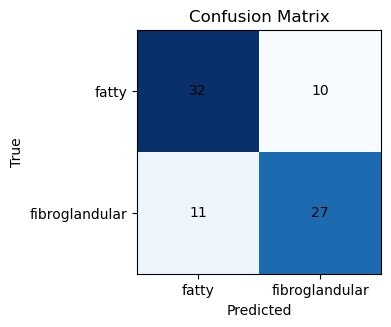

In [12]:
ws_model.fit(X_train_scaled, y_train)

y_pred = ws_model.predict(X_test_scaled)
y_proba = ws_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Test accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"AU-ROC        : {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["fatty", "fibroglandular"]))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["fatty", "fibroglandular"])
plt.yticks([0, 1], ["fatty", "fibroglandular"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()